# 03 Exploratory Data Analysis

**Purpose:** Explore the cleaned retail dataset through univariate, bivariate, and time-series visualizations. Detect outliers and extract initial business insights regarding revenue, product categories, and discounts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (11971, 19)


### Step 1: Outlier Detection using IQR on `total_spent`
**Why:** Extremely high order values can skew our averages (like AOV) and predictive models. We'll identify them using the Interquartile Range (IQR) method.

Identified 60 outliers in total_spent based on IQR bounds.


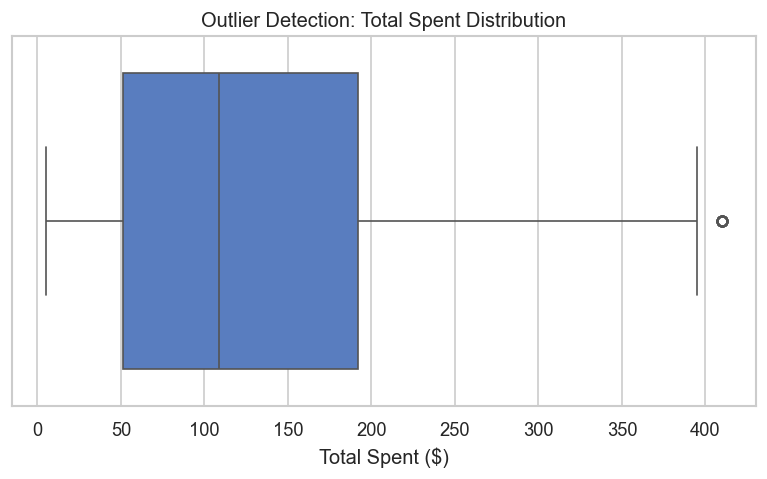

In [2]:
Q1 = df['total_spent'].quantile(0.25)
Q3 = df['total_spent'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[(df['total_spent'] < lower_bound) | (df['total_spent'] > upper_bound)]
print(f"Identified {len(outliers)} outliers in total_spent based on IQR bounds.")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['total_spent'])
plt.title('Outlier Detection: Total Spent Distribution')
plt.xlabel('Total Spent ($)')
plt.show()

**Insight:** The boxplot reveals a long right tail of high-value transactions, indicating rare but significant bulk or high-ticket purchases.

### Step 2: Univariate Analysis - `total_spent` Distribution
**Why:** Understanding the general spread of transaction values helps benchmark typical customer behavior.

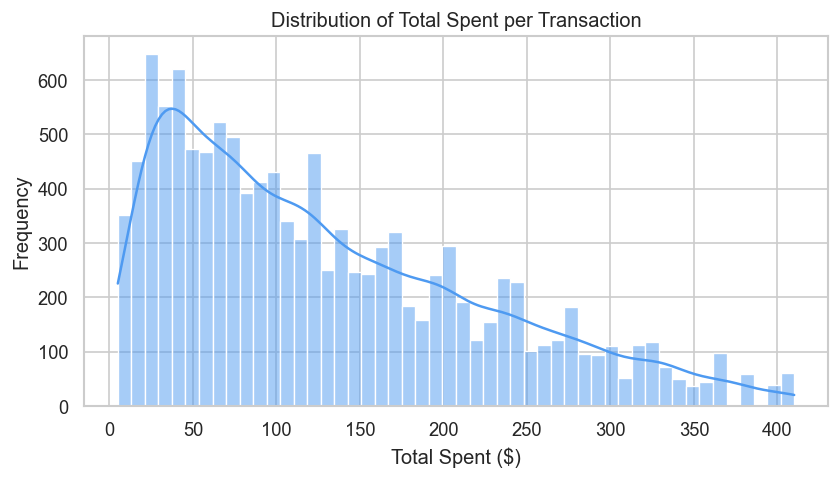

In [3]:
plt.figure(figsize=(8, 4))
sns.histplot(df['total_spent'], bins=50, kde=True, color='#4e9af1')
plt.title('Distribution of Total Spent per Transaction')
plt.xlabel('Total Spent ($)')
plt.ylabel('Frequency')
plt.show()

**Insight:** The transaction value distribution is right-skewed, meaning the majority of orders are small-to-medium sized, with fewer very large orders.

### Step 3: Univariate Analysis - Category Counts & Discount Usage %
**Why:** Examining product category popularity and overall discount penetration.

/var/folders/9n/wgsp0sxs0glgd2vd6zfmpf700000gn/T/ipykernel_80884/1830861465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='Blues_r', ax=axes[0])


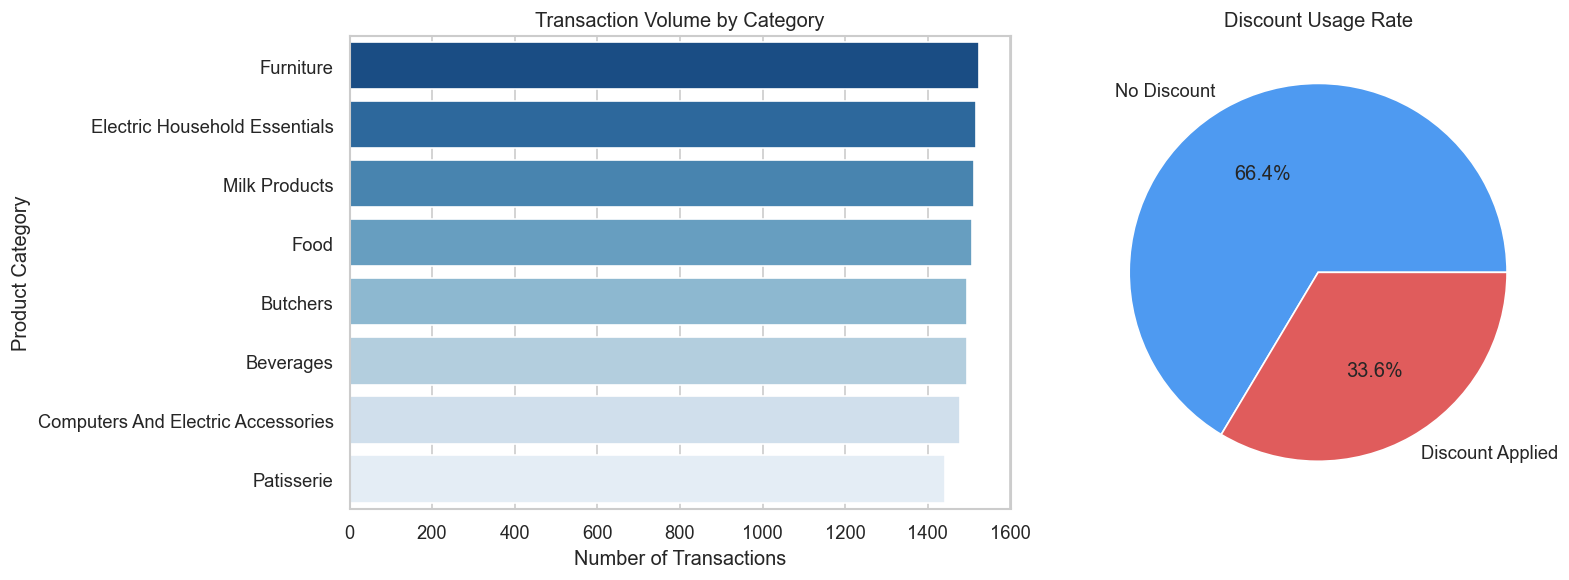

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Transaction Volume by Category')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Product Category')

disc_counts = df['discount_applied'].value_counts()
axes[1].pie(disc_counts, labels=['No Discount', 'Discount Applied'], autopct='%1.1f%%', colors=['#4e9af1', '#e05c5c'])
axes[1].set_title('Discount Usage Rate')

plt.tight_layout()
plt.show()

**Insight:** Certain categories clearly dominate transaction volume, and about one-third of all purchases involve a discount.

### Step 4: Bivariate Analysis - Revenue by Category & Channel
**Why:** Identifying which categories and sales channels (Online vs. In-store) generate the most revenue.

/var/folders/9n/wgsp0sxs0glgd2vd6zfmpf700000gn/T/ipykernel_80884/1499621976.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rev_cat, x='total_spent', y='category', palette='Greens_r', ax=axes[0])
/var/folders/9n/wgsp0sxs0glgd2vd6zfmpf700000gn/T/ipykernel_80884/1499621976.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rev_loc, x='location', y='total_spent', palette='Oranges_r', ax=axes[1])


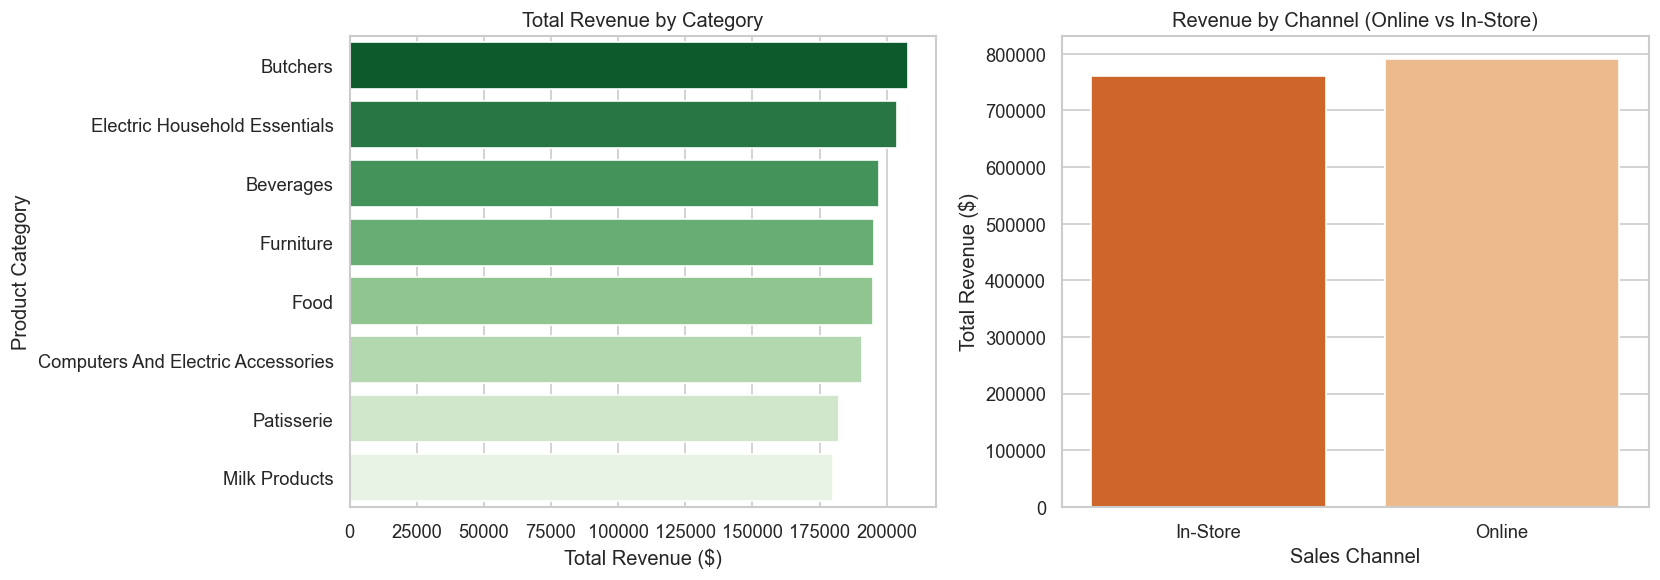

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev_cat = df.groupby('category')['total_spent'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=rev_cat, x='total_spent', y='category', palette='Greens_r', ax=axes[0])
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('Product Category')

rev_loc = df.groupby('location')['total_spent'].sum().reset_index()
sns.barplot(data=rev_loc, x='location', y='total_spent', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Revenue by Channel (Online vs In-Store)')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

**Insight:** Revenue generation is relatively balanced between online and in-store channels, but highly concentrated in top-performing product categories.

### Step 5: Bivariate Analysis - Discount vs Non-Discount AOV
**Why:** Does offering a discount increase or decrease the Average Order Value (AOV)?

/var/folders/9n/wgsp0sxs0glgd2vd6zfmpf700000gn/T/ipykernel_80884/813217609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='discount_applied', y='total_spent', errorbar=None, palette=['#4e9af1', '#e05c5c'])


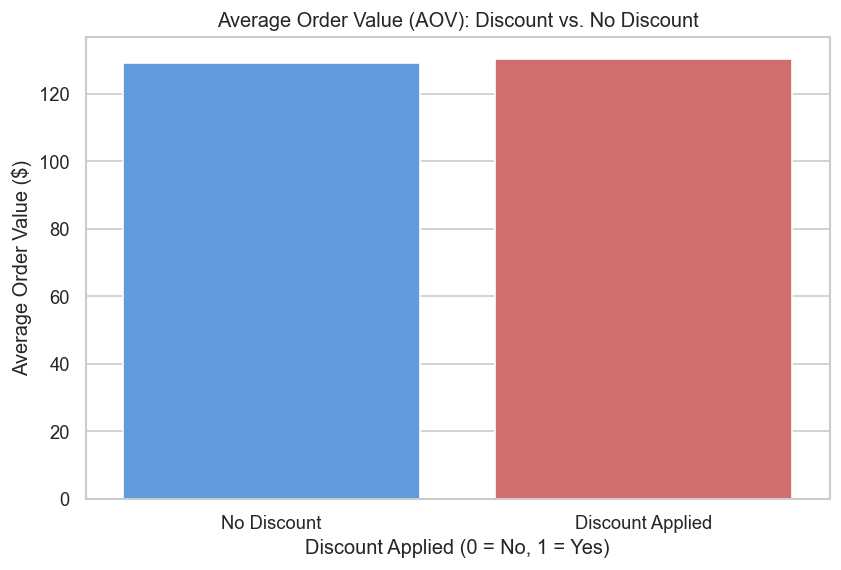

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='discount_applied', y='total_spent', errorbar=None, palette=['#4e9af1', '#e05c5c'])
plt.title('Average Order Value (AOV): Discount vs. No Discount')
plt.xlabel('Discount Applied (0 = No, 1 = Yes)')
plt.ylabel('Average Order Value ($)')
plt.xticks([0, 1], ['No Discount', 'Discount Applied'])
plt.show()

**Insight:** Interestingly, transactions with discounts applied show a slightly higher Average Order Value, suggesting discounts may incentivize larger cart sizes.

### Step 6: Time Series - Monthly Revenue Trend
**Why:** Observing revenue trends over time reveals seasonality and overall growth trajectories.

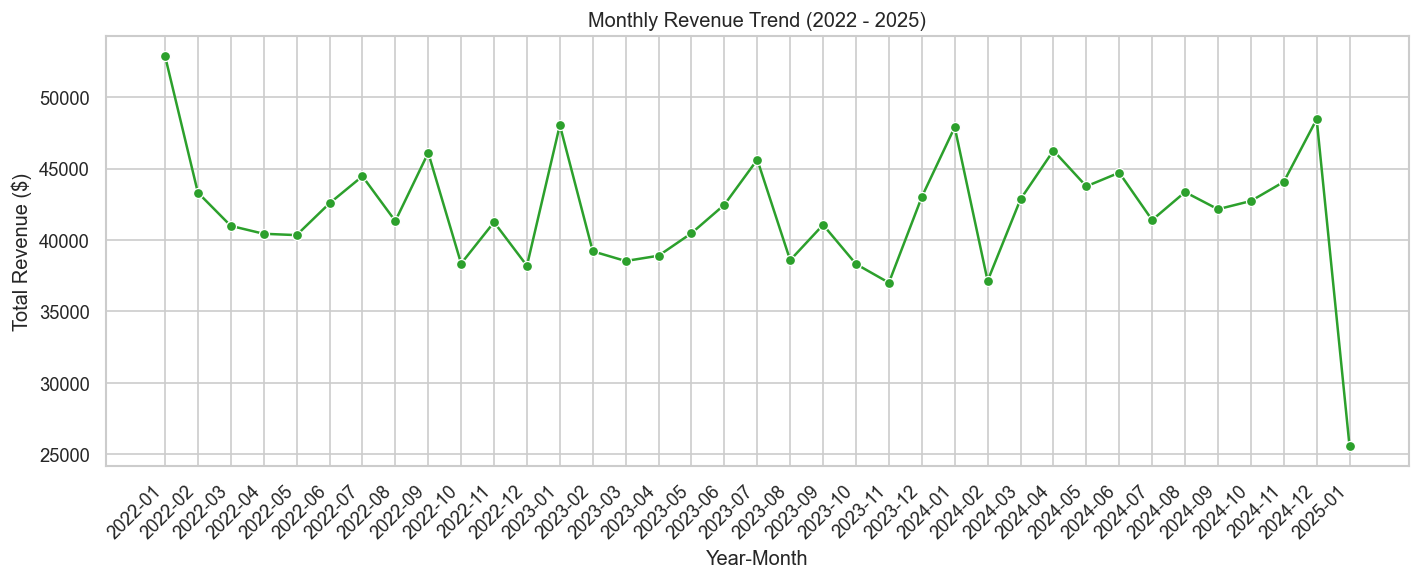

In [7]:
monthly_rev = df.groupby(['transaction_year', 'transaction_month'])['total_spent'].sum().reset_index()
monthly_rev['period'] = monthly_rev['transaction_year'].astype(str) + '-' + monthly_rev['transaction_month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_rev, x='period', y='total_spent', marker='o', color='#2ca02c')
plt.title('Monthly Revenue Trend (2022 - 2025)')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** The monthly revenue trend shows distinct peaks and valleys, indicating clear seasonality in customer purchasing behavior.